# TurathiAI — Dataset Statistics Notebook

Generates the quantitative dataset documentation requested by **Reviewer #1 (Comment 2)** and **Reviewer #2 (Comment 2)**:

- Dataset **size and completeness** (number of complete image/mask/caption triples, missing files)
- **Caption / annotation** statistics (length, vocabulary, top keywords) — *how captions were generated & labeling consistency*
- **Image preprocessing** statistics (resolution, aspect ratio, brightness, near-duplicates)
- **Segmentation-mask** statistics (foreground coverage, bounding-box fill, components, size match)
- Keyword-based **diversity / class balance / over-representation (bias)** analysis

### Expected data layout
A single Google Drive folder holding *all* samples. Files that share the same base name form one set:

| File | Role |
|------|------|
| `NAME.jpg` | building image |
| `NAME-masklabel.png` | segmentation mask |
| `NAME.txt` | caption / annotation |

**How to run:** execute the cells top to bottom. Edit `DATASET_DIR` in the **Config** cell first. All tables and figures are written to `OUTPUT_DIR` in your Drive.

In [1]:
# --- Setup ---
# Optional dependency for near-duplicate image detection (safe to skip if install fails)
!pip -q install imagehash
import os, re, math, collections
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
Image.MAX_IMAGE_PIXELS = None
try:
    import imagehash
    HAVE_IMAGEHASH = True
except Exception:
    HAVE_IMAGEHASH = False
print('imagehash available:', HAVE_IMAGEHASH)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.1 MB/s eta 0:00:00
imagehash available: True


In [2]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ====================== CONFIG (EDIT ME) ======================
# Path to the single Drive folder that holds all the samples:
DATASET_DIR = '/content/drive/MyDrive/CHDB_Full'        # <-- EDIT THIS
OUTPUT_DIR  = '/content/drive/MyDrive/TurathiAI Revision'  # results saved here

IMAGE_EXTS  = ('.jpg', '.jpeg')   # building-image extensions
MASK_SUFFIX = '-masklabel.png'    # mask filename suffix
CAPTION_EXT = '.txt'              # caption extension

# Keyword categories for diversity / over-representation analysis.
# Derived from the paper's annotation template (Table 2). Edit freely.
KEYWORD_CATEGORIES = {
  'Emirate / location': {
     'Abu Dhabi': ['abu dhabi'], 'Dubai': ['dubai'], 'Sharjah': ['sharjah'],
     'Ajman': ['ajman'], 'Ras Al Khaimah': ['ras al khaimah', 'ras al-khaimah'],
     'Fujairah': ['fujairah'], 'Umm Al Quwain': ['umm al quwain'],
  },
  'Design orientation': {
     'Heritage / traditional': ['heritage', 'traditional', 'historic'],
     'Modern / contemporary': ['modern', 'contemporary', 'reinterpret'],
     'Fusion': ['fusion', 'blend', 'hybrid'],
  },
  'View / perspective': {
     'Exterior': ['exterior', 'elevation', 'facade', 'façade', 'front view', 'side view'],
     'Interior': ['interior', 'indoor', 'inside', 'majlis'],
     'Close-up / detail': ['close-up', 'close up', 'detail', 'motif'],
  },
  'Building element': {
     'Wind tower (barjeel)': ['wind tower', 'windtower', 'wind catcher', 'barjeel', 'barjeil'],
     'Mashrabiya / screen': ['mashrabiya', 'wooden screen', 'screen'],
     'Arch': ['arch'], 'Dome': ['dome'], 'Courtyard': ['courtyard'],
     'Parapet': ['parapet'], 'Vaulted roof': ['vault'], 'Flat roof': ['flat roof'],
     'Window': ['window'], 'Door': ['door'], 'Niche': ['niche'],
  },
  'Material': {
     'Coral stone': ['coral stone', 'coral'], 'Gypsum': ['gypsum'],
     'Mud / mortar': ['mud', 'mortar'], 'Plaster': ['plaster'],
     'Sandstone': ['sandstone'], 'Wood': ['wood', 'wooden', 'timber'],
  },
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Reading from :', DATASET_DIR)
print('Saving stats :', OUTPUT_DIR)

Reading from : /content/drive/MyDrive/CHDB_Full
Saving stats : /content/drive/MyDrive/TurathiAI Revision


In [4]:
# --- Index files into samples (grouped by base name) & completeness report ---
def base_name(fn):
    if fn.lower().endswith(MASK_SUFFIX):
        return fn[:-len(MASK_SUFFIX)]
    return os.path.splitext(fn)[0]

assert os.path.isdir(DATASET_DIR), f'DATASET_DIR not found: {DATASET_DIR}'
files = [f for f in os.listdir(DATASET_DIR) if os.path.isfile(os.path.join(DATASET_DIR, f))]
samples = collections.defaultdict(lambda: {'image': None, 'mask': None, 'caption': None})
for f in files:
    low = f.lower(); p = os.path.join(DATASET_DIR, f); b = base_name(f)
    if low.endswith(MASK_SUFFIX):
        samples[b]['mask'] = p
    elif low.endswith(CAPTION_EXT):
        samples[b]['caption'] = p
    elif low.endswith(IMAGE_EXTS):
        samples[b]['image'] = p

index = pd.DataFrame([
    {'sample': b, 'has_image': v['image'] is not None,
     'has_mask': v['mask'] is not None, 'has_caption': v['caption'] is not None}
    for b, v in sorted(samples.items())
])
index['complete'] = index[['has_image', 'has_mask', 'has_caption']].all(axis=1)
n_sets = len(index); n_complete = int(index['complete'].sum())
print(f'Total files scanned                      : {len(files)}')
print(f'Distinct sample sets                     : {n_sets}')
print(f'Complete triples (image+mask+caption)    : {n_complete}')
print(f'Incomplete sets                          : {n_sets - n_complete}')
print(f'  missing image   : {int((~index["has_image"]).sum())}')
print(f'  missing mask    : {int((~index["has_mask"]).sum())}')
print(f'  missing caption : {int((~index["has_caption"]).sum())}')
if (~index['complete']).any():
    print('\nExamples of incomplete sets:')
    display(index[~index['complete']].head(20))
index.to_csv(os.path.join(OUTPUT_DIR, 'sample_index.csv'), index=False)

Total files scanned                      : 1903
Distinct sample sets                     : 634
Complete triples (image+mask+caption)    : 634
Incomplete sets                          : 0
  missing image   : 0
  missing mask    : 0
  missing caption : 0


Captions analyzed: 634


,words,chars,unique_words
count,634.00,634.00,634.00
mean,80.84,496.52,50.78
std,50.78,301.74,24.27
min,20.00,121.00,16.00
5%,30.00,192.65,24.00
25%,48.00,296.00,35.00
50%,69.00,445.00,47.00
75%,92.00,561.00,56.00
95%,176.35,1054.70,101.35
max,408.00,2380.00,178.00


Total tokens: 51251 | Vocabulary size: 919


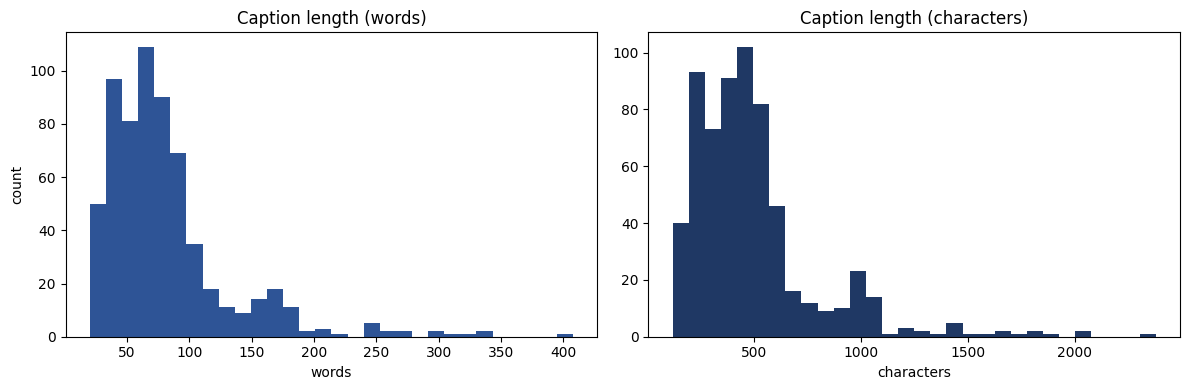


Top content keywords:


,keyword,frequency
0,wall,1311
1,door,1106
2,emirati,962
3,wooden,732
4,rectangular,694
5,up,556
6,close,554
7,window,548
8,niche,546
9,heritage,539


In [5]:
# --- Caption / annotation statistics (addresses: how captions were generated, labeling consistency) ---
TOKEN_RE = re.compile(r"[a-zA-ZÀ-ɏ']+")
cap_rows, all_tokens = [], []
for b, v in samples.items():
    if not v['caption']:
        continue
    try:
        text = open(v['caption'], encoding='utf-8', errors='ignore').read().strip()
    except Exception:
        text = ''
    toks = [t.lower() for t in TOKEN_RE.findall(text)]
    all_tokens.extend(toks)
    cap_rows.append({'sample': b, 'chars': len(text), 'words': len(toks),
                     'unique_words': len(set(toks))})
cap = pd.DataFrame(cap_rows)
print('Captions analyzed:', len(cap))
if len(cap):
    display(cap[['words', 'chars', 'unique_words']].describe(percentiles=[.05, .25, .5, .75, .95]).round(2))
    vocab = collections.Counter(all_tokens)
    print('Total tokens:', sum(vocab.values()), '| Vocabulary size:', len(vocab))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(cap['words'], bins=30, color='#2E5496'); ax[0].set_title('Caption length (words)'); ax[0].set_xlabel('words'); ax[0].set_ylabel('count')
    ax[1].hist(cap['chars'], bins=30, color='#1F3864'); ax[1].set_title('Caption length (characters)'); ax[1].set_xlabel('characters')
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'caption_length.png'), dpi=150); plt.show()
    STOP = set('a an the of and or to in on with is are was were for from this that it its as at by be been has have had building house design'.split())
    common = [(w, c) for w, c in vocab.most_common(80) if w not in STOP][:30]
    print('\nTop content keywords:')
    display(pd.DataFrame(common, columns=['keyword', 'frequency']))
    cap.to_csv(os.path.join(OUTPUT_DIR, 'caption_stats.csv'), index=False)

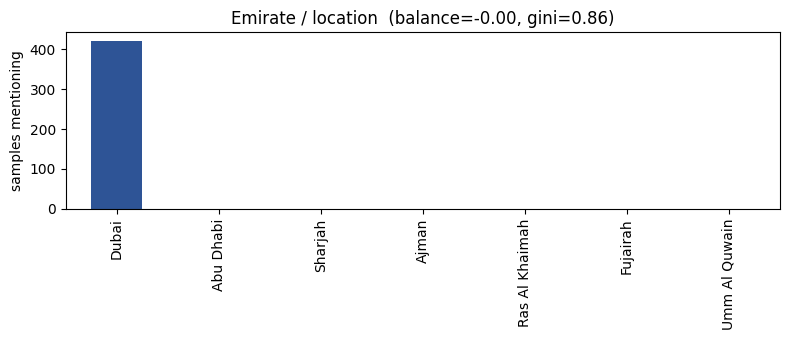

,count
Dubai,422
Abu Dhabi,0
Sharjah,0
Ajman,0
Ras Al Khaimah,0
Fujairah,0
Umm Al Quwain,0


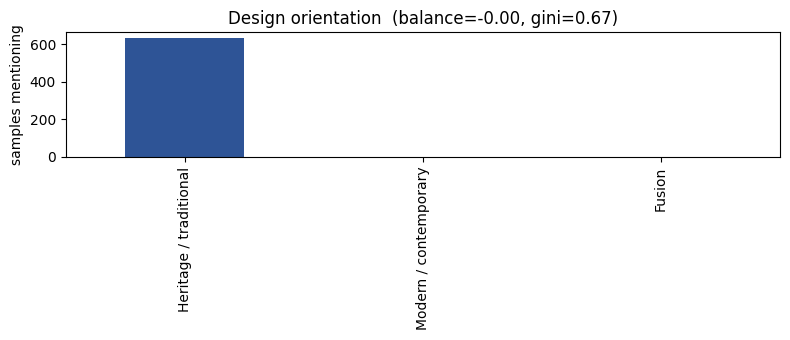

,count
Heritage / traditional,632
Modern / contemporary,0
Fusion,0


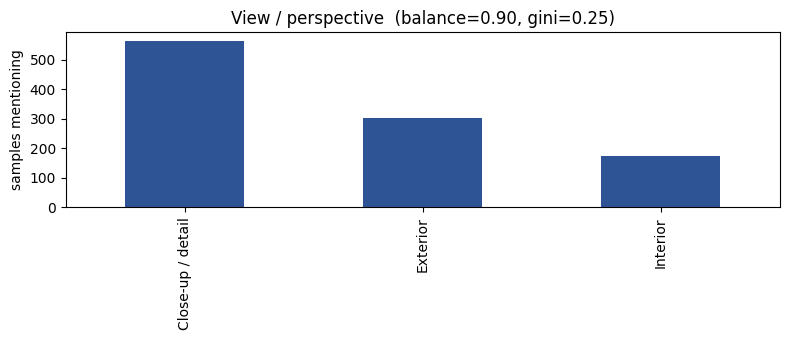

,count
Close-up / detail,564
Exterior,303
Interior,174


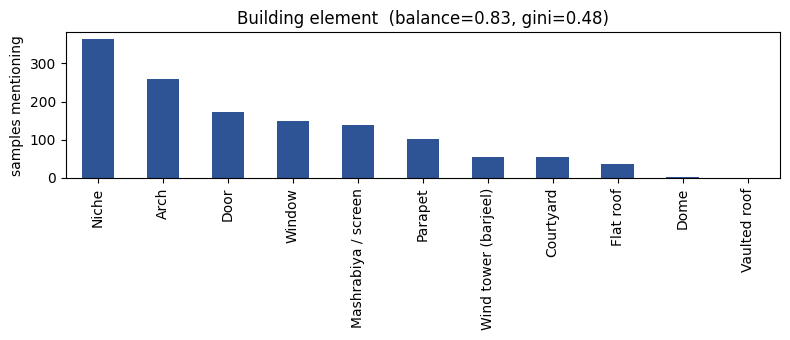

,count
Niche,363
Arch,259
Door,172
Window,148
Mashrabiya / screen,139
Parapet,103
Wind tower (barjeel),55
Courtyard,55
Flat roof,36
Dome,3


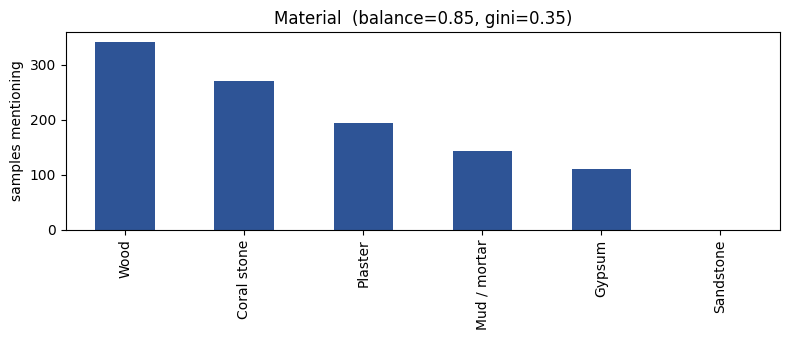

,count
Wood,342
Coral stone,271
Plaster,194
Mud / mortar,143
Gypsum,111
Sandstone,0



Interpretation: balance closer to 1 = more even coverage; higher gini = stronger over-representation of a few classes.


,category,classes,classes_present,samples_tagged,balance_0to1,gini_0to1,top_class,top_count
0,Emirate / location,7,1,422,-0.000,0.857,Dubai,422
1,Design orientation,3,1,632,-0.000,0.667,Heritage / traditional,632
2,View / perspective,3,3,1041,0.901,0.250,Close-up / detail,564
3,Building element,11,10,1333,0.829,0.480,Niche,363
4,Material,6,5,1061,0.854,0.352,Wood,342


In [6]:
# --- Diversity, class balance & over-representation (bias) from caption keywords ---
def entropy(counts):
    tot = sum(counts)
    if tot == 0: return 0.0
    return -sum((c/tot) * math.log2(c/tot) for c in counts if c > 0)

def gini(counts):
    xs = sorted(counts); n = len(xs); s = sum(xs)
    if n == 0 or s == 0: return 0.0
    cum = sum((i + 1) * x for i, x in enumerate(xs))
    return (2 * cum) / (n * s) - (n + 1) / n

texts = {b: (open(v['caption'], encoding='utf-8', errors='ignore').read().lower() if v['caption'] else '')
         for b, v in samples.items()}
summary_balance = []
for cat, classes in KEYWORD_CATEGORIES.items():
    counts = {cls: sum(1 for t in texts.values() if any(k in t for k in kws)) for cls, kws in classes.items()}
    s = pd.Series(counts).sort_values(ascending=False)
    H = entropy(list(s.values)); Hmax = math.log2(len(s)) if len(s) > 1 else 1
    bal = (H / Hmax) if Hmax > 0 else 0.0
    g = gini(list(s.values))
    summary_balance.append({'category': cat, 'classes': len(s), 'classes_present': int((s > 0).sum()),
                            'samples_tagged': int(s.sum()), 'balance_0to1': round(bal, 3),
                            'gini_0to1': round(g, 3), 'top_class': s.index[0], 'top_count': int(s.iloc[0])})
    plt.figure(figsize=(8, 3.5)); s.plot(kind='bar', color='#2E5496')
    plt.title(f'{cat}  (balance={bal:.2f}, gini={g:.2f})'); plt.ylabel('samples mentioning'); plt.tight_layout()
    safe = re.sub(r'[^A-Za-z0-9]+', '_', cat).strip('_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'category_{safe}.png'), dpi=150); plt.show()
    display(s.rename('count').to_frame())
bal_df = pd.DataFrame(summary_balance)
print('\nInterpretation: balance closer to 1 = more even coverage; higher gini = stronger over-representation of a few classes.')
display(bal_df)
bal_df.to_csv(os.path.join(OUTPUT_DIR, 'diversity_balance.csv'), index=False)

Images analyzed: 634


,width,height,megapixels,aspect_ratio,file_kb,mean_brightness
count,634.00,634.00,634.00,634.00,634.00,634.00
mean,5459.52,3899.65,21.43,1.41,6787.29,162.99
std,904.74,616.39,4.88,0.20,3092.51,23.05
min,3024.00,3024.00,12.19,0.67,1440.40,59.30
5%,4000.00,3024.00,12.19,0.75,2178.84,124.76
50%,6000.00,4000.00,24.00,1.50,7078.15,165.05
95%,6000.00,4032.00,24.00,1.50,11931.23,198.57
max,6000.00,6000.00,24.00,1.50,14896.00,230.70


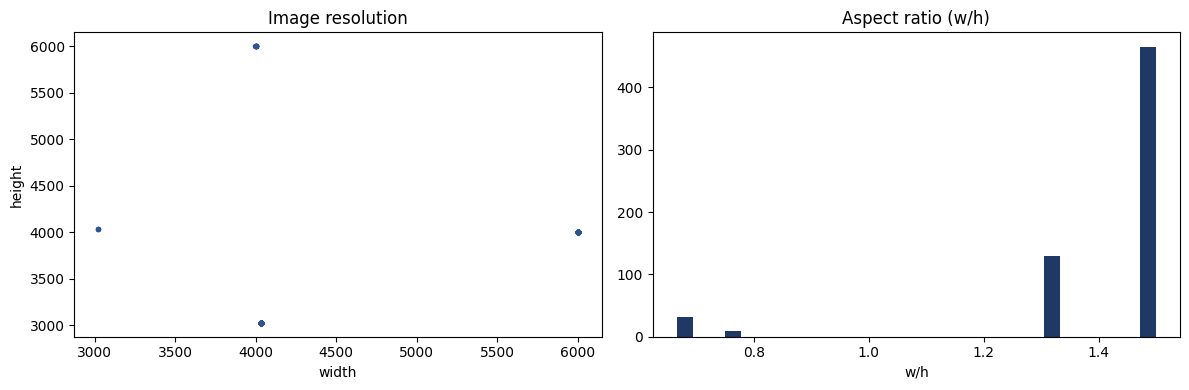

Potential near-duplicate pairs (phash Hamming <= 5): 1


,sample_a,sample_b,hamming
0,folder 7_ventilation screen 7,folder 7_ventilation screen 8,2


In [7]:
# --- Image statistics (preprocessing: resolution, aspect ratio, brightness, near-duplicates) ---
img_rows, phashes = [], {}
for b, v in samples.items():
    if not v['image']:
        continue
    try:
        with Image.open(v['image']) as im:
            w, h = im.size; mode = im.mode
            arr = np.asarray(im.convert('RGB'), dtype=np.float32)
        img_rows.append({'sample': b, 'width': w, 'height': h, 'megapixels': round(w * h / 1e6, 3),
                         'aspect_ratio': round(w / h, 3), 'mode': mode,
                         'file_kb': round(os.path.getsize(v['image']) / 1024.0, 1),
                         'mean_brightness': round(float(arr.mean()), 1)})
        if HAVE_IMAGEHASH:
            with Image.open(v['image']) as im2:
                phashes[b] = imagehash.phash(im2)
    except Exception as e:
        img_rows.append({'sample': b, 'error': str(e)})
img = pd.DataFrame(img_rows)
print('Images analyzed:', len(img))
if len(img) and 'width' in img:
    display(img[['width', 'height', 'megapixels', 'aspect_ratio', 'file_kb', 'mean_brightness']]
            .describe(percentiles=[.05, .5, .95]).round(2))
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(img['width'], img['height'], s=8, alpha=.5, color='#2E5496'); ax[0].set_title('Image resolution'); ax[0].set_xlabel('width'); ax[0].set_ylabel('height')
    ax[1].hist(img['aspect_ratio'].dropna(), bins=30, color='#1F3864'); ax[1].set_title('Aspect ratio (w/h)'); ax[1].set_xlabel('w/h')
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'image_resolution.png'), dpi=150); plt.show()
    img.to_csv(os.path.join(OUTPUT_DIR, 'image_stats.csv'), index=False)
    if HAVE_IMAGEHASH and len(phashes) > 1:
        items = list(phashes.items()); dups = []
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                d = items[i][1] - items[j][1]
                if d <= 5:
                    dups.append({'sample_a': items[i][0], 'sample_b': items[j][0], 'hamming': d})
        print('Potential near-duplicate pairs (phash Hamming <= 5):', len(dups))
        if dups:
            display(pd.DataFrame(dups).sort_values('hamming').head(30))

Masks analyzed: 634


,fg_coverage,bbox_fill_ratio,components
count,634.000,634.000,634.000
mean,0.720,0.883,1.076
std,0.244,0.133,0.447
min,0.076,0.332,1.000
5%,0.250,0.618,1.000
50%,0.750,0.932,1.000
95%,1.000,1.000,1.000
max,1.000,1.000,8.000


Masks matching image resolution: 352/634


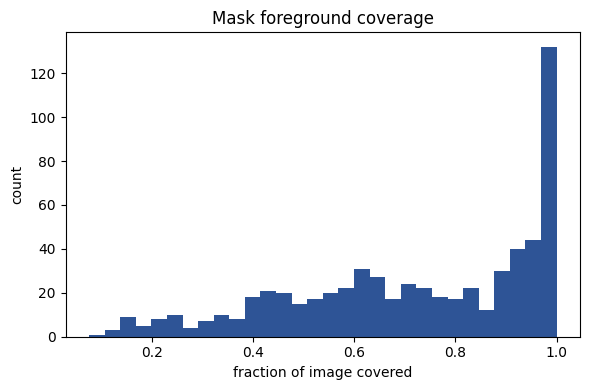

In [8]:
# --- Mask statistics (foreground coverage, bounding-box fill, components, size match) ---
try:
    from scipy import ndimage
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False
mask_rows = []
for b, v in samples.items():
    if not v['mask']:
        continue
    try:
        with Image.open(v['mask']) as mk:
            m = np.asarray(mk.convert('L'))
        fg = m > 127; h, w = fg.shape; area = int(fg.sum())
        cov = area / (h * w) if h * w else 0.0
        if area > 0:
            ys, xs = np.where(fg)
            bb = (xs.max() - xs.min() + 1) * (ys.max() - ys.min() + 1)
            fill = area / bb if bb else 0.0
        else:
            fill = 0.0
        ncomp = int(ndimage.label(fg)[1]) if HAVE_SCIPY else None
        size_match = None
        if v['image']:
            try:
                with Image.open(v['image']) as im:
                    size_match = (im.size == (w, h))
            except Exception:
                pass
        mask_rows.append({'sample': b, 'mask_w': w, 'mask_h': h, 'fg_coverage': round(float(cov), 4),
                          'bbox_fill_ratio': round(float(fill), 4), 'components': ncomp,
                          'matches_image_size': size_match})
    except Exception as e:
        mask_rows.append({'sample': b, 'error': str(e)})
mask = pd.DataFrame(mask_rows)
print('Masks analyzed:', len(mask))
if len(mask) and 'fg_coverage' in mask:
    display(mask[['fg_coverage', 'bbox_fill_ratio', 'components']].describe(percentiles=[.05, .5, .95]).round(3))
    if 'matches_image_size' in mask:
        ok = int(mask['matches_image_size'].fillna(False).sum()); tot = int(mask['matches_image_size'].notna().sum())
        print(f'Masks matching image resolution: {ok}/{tot}')
    plt.figure(figsize=(6, 4)); plt.hist(mask['fg_coverage'].dropna(), bins=30, color='#2E5496')
    plt.title('Mask foreground coverage'); plt.xlabel('fraction of image covered'); plt.ylabel('count')
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'mask_coverage.png'), dpi=150); plt.show()
    mask.to_csv(os.path.join(OUTPUT_DIR, 'mask_stats.csv'), index=False)

In [9]:
# --- Consolidated summary (paste-ready numbers for the rebuttal) ---
summary = {
    'Total files scanned': len(files),
    'Distinct sample sets': int(n_sets),
    'Complete triples (image+mask+caption)': int(n_complete),
    'Incomplete sets': int(n_sets - n_complete),
}
if len(cap):
    summary['Captions: mean words'] = round(float(cap['words'].mean()), 1)
    summary['Captions: median words'] = float(cap['words'].median())
    summary['Captions: mean characters'] = round(float(cap['chars'].mean()), 1)
    summary['Captions: vocabulary size'] = len(set(all_tokens))
if len(img) and 'width' in img:
    summary['Images: median resolution'] = f"{int(img['width'].median())}x{int(img['height'].median())}"
    summary['Images: median megapixels'] = round(float(img['megapixels'].median()), 2)
if len(mask) and 'fg_coverage' in mask:
    summary['Masks: mean foreground coverage'] = round(float(mask['fg_coverage'].mean()), 3)
    if 'matches_image_size' in mask:
        summary['Masks matching image size'] = f"{int(mask['matches_image_size'].fillna(False).sum())}/{int(mask['matches_image_size'].notna().sum())}"
summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
display(summary_df)
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'SUMMARY.csv'), index=False)
print('\nAll CSVs and figures saved to:', OUTPUT_DIR)
print('Files:', sorted(os.listdir(OUTPUT_DIR)))

,Metric,Value
0,Total files scanned,1903
1,Distinct sample sets,634
2,Complete triples (image+mask+caption),634
3,Incomplete sets,0
4,Captions: mean words,80.8
5,Captions: median words,69.0
6,Captions: mean characters,496.5
7,Captions: vocabulary size,919
8,Images: median resolution,6000x4000
9,Images: median megapixels,24.0



All CSVs and figures saved to: /content/drive/MyDrive/TurathiAI Revision
Files: ['SUMMARY.csv', 'TurathiAI_Dataset_Statistics.ipynb', 'caption_length.png', 'caption_stats.csv', 'category_Building_element.png', 'category_Design_orientation.png', 'category_Emirate_location.png', 'category_Material.png', 'category_View_perspective.png', 'diversity_balance.csv', 'image_resolution.png', 'image_stats.csv', 'mask_coverage.png', 'mask_stats.csv', 'sample_index.csv']


## Using these outputs in the rebuttal

Map each output to the reviewer's sub-points (Reviewer #1 C2 / Reviewer #2 C2):

- **Acquisition protocol & quantitative details** → `SUMMARY.csv` and `sample_index.csv`: total samples, complete triples, missing-file counts.
- **How captions were generated & labeling consistency** → `caption_stats.csv` + caption-length figure: mean/median caption length, vocabulary size, and the top-keyword table (consistent template-driven vocabulary signals labeling consistency across the three annotators).
- **Preprocessing of the images** → `image_stats.csv` + resolution/aspect-ratio figures, plus the near-duplicate check.
- **Segmentation quality** → `mask_stats.csv` + coverage figure: foreground coverage, bounding-box fill, component counts, and image/mask size agreement.
- **Class balancing, diversity, style over-representation & bias** → `diversity_balance.csv` + per-category bar charts: the **balance** (normalized entropy, 0–1) and **gini** (0–1) scores quantify how evenly the dataset covers emirates, design orientations, building elements, and materials. Low balance / high gini flags over-representation you can discuss and, if needed, mitigate.

> Note: the diversity analysis infers categories from caption keywords. If you maintain a separate structured metadata file (e.g., per-sample emirate or style labels), point the category logic at that for exact counts. Inter-annotator agreement requires per-annotator labels, which are not derivable from merged captions alone.